In [ ]:
# Summarizes crash counts, fatalities, serious injuries, and total injuries under different environmental conditions.
# Use bar charts and heatmaps to identify whether certain lighting or weather settings are associated with higher
# crash severity.
# Road condition combinations are selected to show UTM coordinates and show where severe crashes occurred

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns


In [2]:
df = pd.read_csv("2012-24_Crash_Events_std_street_names_dataset.csv" )

C:\Users\Eric Zhang\AppData\Local\Temp\ipykernel_14852\16772373.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("2012-24_Crash_Events_std_street_names_dataset.csv" )


In [3]:
df.head()

,CaseNumber,CaseYear,CrashDate,CrashTime,CrashTimeFormatted,CrashTypeCde,CrashType,CollisionType,CrashSeverity,LightCondition,...,DriverAgeVehicleOne,DriverAgeVehicleTwo,DriverAgeVehicleThree,DriverAgeVehicleFour,DriverAgeVehicleFive,PersonTypes,PersonInjuries,ApparentFactors,ApparentFactorCodes,OnStreet_standardized
0,36996805,2017,2017-11-22,2353.0,11:53 PM,7,COLLISION WITH DEER,OTHER,PROPERTY DAMAGE,DARK-ROAD UNLIGHTED,...,58.0,NaN,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(ANIMALS ACTION,NOT APPLICABLE)",|61|777|,STATE ROUTE 104
1,37791267,2019,2019-02-20,615.0,6:15 AM,7,COLLISION WITH DEER,OTHER,PROPERTY DAMAGE,DAWN,...,26.0,NaN,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(NOT ENTERED,NOT ENTERED)",|888|888|,STATE ROUTE 104
2,37328049,2018,2018-06-04,723.0,7:23 AM,1,COLLISION WITH MOTOR VEHICLE,OTHER,PROPERTY DAMAGE,DAYLIGHT,...,34.0,0.0,0.0,NaN,NaN,U1:(DRIVER) / U2:(DRIVER) / U3:(DRIVER),U1:(U - UNKNOWN) / U2:(U - UNKNOWN) / U3:(U - ...,"V1:(FOLLOWING TOO CLOSELY,NOT APPLICABLE) / V2...",|9|777|777|777|777|777|,STATE ROUTE 104
3,36064247,2016,2016-01-18,2305.0,11:05 PM,14,COLLISION WITH SIGN POST,OTHER,PROPERTY DAMAGE,DARK-ROAD LIGHTED,...,23.0,NaN,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(PAVEMENT SLIPPERY,UNSAFE SPEED)",|66|19|,STATE ROUTE 104
4,36593945,2017,2017-01-08,0.0,12:00 AM,12,COLLISION WITH GUIDE RAIL,OTHER,PROPERTY DAMAGE,UNKNOWN,...,52.0,NaN,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(NOT ENTERED,NOT ENTERED)",|888|888|,STATE ROUTE 104


In [4]:
df.columns

Index(['CaseNumber', 'CaseYear', 'CrashDate', 'CrashTime',
       'CrashTimeFormatted', 'CrashTypeCde', 'CrashType', 'CollisionType',
       'CrashSeverity', 'LightCondition', 'WeatherCondition',
       'RoadwayAccessControlCde', 'RoadwayCharacteristic',
       'RoadSurfaceCondition', 'TrafficControl', 'TrafficWay',
       'MaxInjurySeverity', 'NumberOfFatalities', 'NumberOfInjuries',
       'NumberOfSeriousInjuries', 'NumberOfOtherInjuries', 'NumberOfVehicles',
       'PoliceDept', 'ReportingAgency', 'Precinct',
       'CommercialVehicleCrashInd', 'PPDRCode', 'NonReportable',
       'ReviewedIndicator', 'DMVInsertDate', 'CountyFIPS', 'CountyName',
       'MuniFIPS', 'CityTownName', 'OnStreet', 'ClosestCrossStreet',
       'MasterIntersectionId', 'IntersectionIndicator', 'ReferenceMarker',
       'DistanceFromIntersection', 'DirectionFromIntersection', 'UTMEasting',
       'UTMNorthing', 'NonPublicWayCode', 'ACCESS_CONTROL', 'DIVIDED',
       'FUNCTIONAL_CLASS', 'MAINT_JURISDICTION_TYP

In [5]:
top10 = [
    "INTERSTATE 490",
    "LAKE AVENUE",
    "DEWEY AVENUE",
    "STATE ROUTE 104",
    "WEST RIDGE ROAD",
    "LYELL AVENUE",
    "CHILI AVENUE",
    "HUDSON AVENUE",
    "CLIFFORD AVENUE",
    "WEST HENRIETTA ROAD"
]

In [6]:
df["LightCondition"].value_counts()

LightCondition
DAYLIGHT               195849
DARK-ROAD LIGHTED       57729
DARK-ROAD UNLIGHTED     20344
DUSK                     6965
DAWN                     5161
UNKNOWN                  4537
NOT ENTERED              1049
Name: count, dtype: int64

In [38]:
df["LightCondition_cleaned"] = df["LightCondition"].replace({"NOT ENTERED": "UNKNOWN"})

In [39]:
df["LightCondition_cleaned"].value_counts()

LightCondition_cleaned
DAYLIGHT               195849
DARK-ROAD LIGHTED       57729
DARK-ROAD UNLIGHTED     20344
DUSK                     6965
UNKNOWN                  5586
DAWN                     5161
Name: count, dtype: int64

In [41]:
df["WeatherCondition"].value_counts()
df["WeatherCondition_cleaned"] = df["WeatherCondition"].replace({"OTHER": "UNKNOWN","NOT ENTERED": "UNKNOWN"})

In [42]:
df["WeatherCondition_cleaned"].value_counts()

WeatherCondition_cleaned
CLEAR                        155264
CLOUDY                        79389
RAIN                          24554
SNOW                          23770
UNKNOWN                        6692
SLEET/HAIL/FREEZING RAIN       1736
FOG/SMOG/SMOKE                  229
Name: count, dtype: int64

In [43]:
df10 = df[df["OnStreet_standardized"].isin(top10)].copy()

In [44]:
df10.head()

,CaseNumber,CaseYear,CrashDate,CrashTime,CrashTimeFormatted,CrashTypeCde,CrashType,CollisionType,CrashSeverity,LightCondition,...,DriverAgeVehicleThree,DriverAgeVehicleFour,DriverAgeVehicleFive,PersonTypes,PersonInjuries,ApparentFactors,ApparentFactorCodes,OnStreet_standardized,LightCondition_cleaned,WeatherCondition_cleaned
0,36996805,2017,2017-11-22,2353.0,11:53 PM,7,COLLISION WITH DEER,OTHER,PROPERTY DAMAGE,DARK-ROAD UNLIGHTED,...,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(ANIMALS ACTION,NOT APPLICABLE)",|61|777|,STATE ROUTE 104,DARK-ROAD UNLIGHTED,CLOUDY
1,37791267,2019,2019-02-20,615.0,6:15 AM,7,COLLISION WITH DEER,OTHER,PROPERTY DAMAGE,DAWN,...,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(NOT ENTERED,NOT ENTERED)",|888|888|,STATE ROUTE 104,DAWN,CLEAR
2,37328049,2018,2018-06-04,723.0,7:23 AM,1,COLLISION WITH MOTOR VEHICLE,OTHER,PROPERTY DAMAGE,DAYLIGHT,...,0.0,NaN,NaN,U1:(DRIVER) / U2:(DRIVER) / U3:(DRIVER),U1:(U - UNKNOWN) / U2:(U - UNKNOWN) / U3:(U - ...,"V1:(FOLLOWING TOO CLOSELY,NOT APPLICABLE) / V2...",|9|777|777|777|777|777|,STATE ROUTE 104,DAYLIGHT,CLOUDY
3,36064247,2016,2016-01-18,2305.0,11:05 PM,14,COLLISION WITH SIGN POST,OTHER,PROPERTY DAMAGE,DARK-ROAD LIGHTED,...,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(PAVEMENT SLIPPERY,UNSAFE SPEED)",|66|19|,STATE ROUTE 104,DARK-ROAD LIGHTED,SNOW
4,36593945,2017,2017-01-08,0.0,12:00 AM,12,COLLISION WITH GUIDE RAIL,OTHER,PROPERTY DAMAGE,UNKNOWN,...,NaN,NaN,NaN,U1:(DRIVER),U1:(U - UNKNOWN),"V1:(NOT ENTERED,NOT ENTERED)",|888|888|,STATE ROUTE 104,UNKNOWN,UNKNOWN


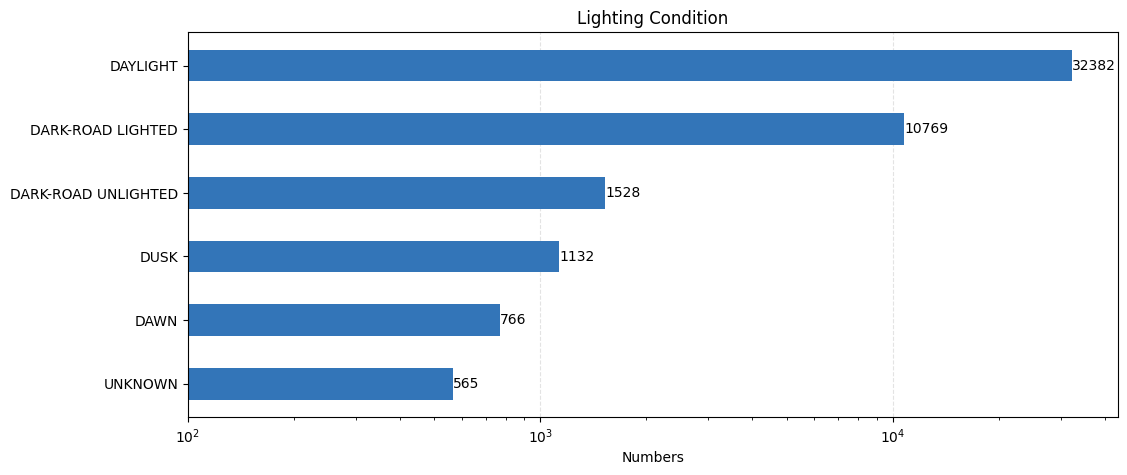

In [89]:
lc = df10["LightCondition_cleaned"].value_counts()

t_labels = lc[::-1].index
t_values = lc[::-1].values
t_labels = t_labels.astype(str)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(t_labels, t_values, height=0.5, color = '#3375B8')
ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.set_xscale("log") 
for index, j in enumerate(t_values):
    plt.text(j, index, str(j), va= "center", ha= "left", fontsize = 10)

plt.title("Lighting Condition")
plt.xlabel("Numbers")

axis = plt.gca()
axis.set_xlim(100, axis.get_xlim()[1] * 1.1)
plt.show()


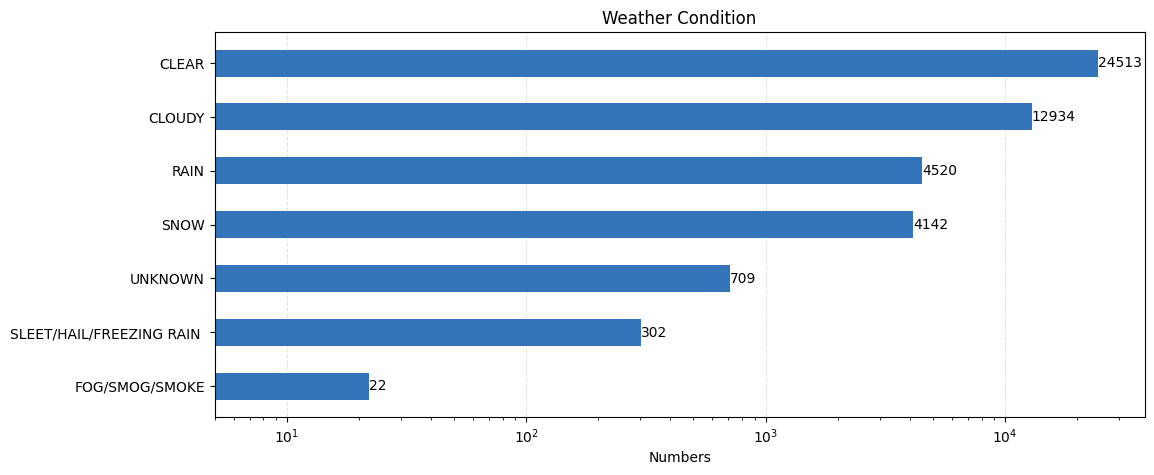

In [90]:
wc = df10["WeatherCondition_cleaned"].value_counts()

t_labels = wc[::-1].index
t_values = wc[::-1].values
t_labels = t_labels.astype(str)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(t_labels, t_values, height = 0.5, color = '#3375B8')
ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.set_xscale("log") 
for index, j in enumerate(t_values):
    plt.text(j, index, str(j), va= "center", ha= "left", fontsize = 10)

plt.title("Weather Condition")
plt.xlabel("Numbers")

axis = plt.gca()
axis.set_xlim(5, axis.get_xlim()[1] * 1.1)
plt.show()


In [57]:
g1 = (df10.groupby("LightCondition_cleaned").agg(Crashes = ("LightCondition_cleaned", "size"), Fatalities = ("NumberOfFatalities", "sum"),
    SeriousInjuries = ("NumberOfSeriousInjuries", "sum"),Injuries  = ("NumberOfInjuries", "sum")))

g1["Fatality_rate"] = g1["Fatalities"] / g1["Crashes"]
g1["SeriousInjuries_rate"] = g1["SeriousInjuries"] / g1["Crashes"]
g1["Injuries_rate"] = g1["Injuries"] / g1["Crashes"]
g1 = g1.sort_values("Fatality_rate", ascending = False)
g1

,Crashes,Fatalities,SeriousInjuries,Injuries,Fatality_rate,SeriousInjuries_rate,Injuries_rate
LightCondition_cleaned,,,,,,,
DARK-ROAD LIGHTED,10769,48,442,3265,0.004457,0.041044,0.303185
DAWN,766,3,17,189,0.003916,0.022193,0.246736
DUSK,1132,4,41,312,0.003534,0.036219,0.275618
DARK-ROAD UNLIGHTED,1528,5,36,252,0.003272,0.023560,0.164921
DAYLIGHT,32382,47,691,8791,0.001451,0.021339,0.271478
UNKNOWN,565,0,2,42,0.000000,0.003540,0.074336


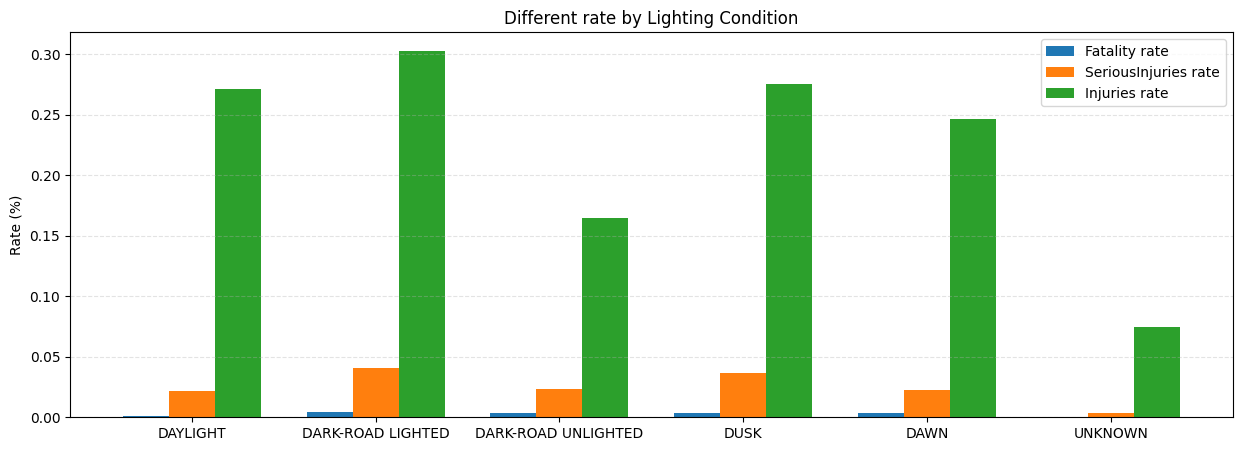

In [82]:

plot1_df = g1.copy()

order = ["DAYLIGHT","DARK-ROAD LIGHTED","DARK-ROAD UNLIGHTED","DUSK","DAWN","UNKNOWN"]
plot1_df = plot1_df.reindex([x for x in order if x in plot1_df.index])

f = plot1_df.index.tolist()
x = np.arange(len(f))
w = 0.25

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w, plot_df["Fatality_rate"] , width = w, label= "Fatality rate")
ax.bar(x,     plot_df["SeriousInjuries_rate"] , width = w, label= "SeriousInjuries rate")
ax.bar(x + w, plot_df["Injuries_rate"], width = w, label = "Injuries rate")



ax.set_xticks(x)
ax.set_xticklabels(f)
ax.set_ylabel("Rate (%)")
ax.set_title("Different rate by Lighting Condition")

ax.yaxis.grid(True, linestyle="--", alpha = 0.35)
ax.legend()
plt.show()

In [135]:
g2 = (df10.groupby("WeatherCondition_cleaned").agg(Crashes =("WeatherCondition_cleaned","size"), Fatalities = ("NumberOfFatalities","sum"),
    SeriousInjuries=("NumberOfSeriousInjuries","sum"),Injuries=("NumberOfInjuries","sum")))

g2["Fatality_rate"] = g2["Fatalities"] / g2["Crashes"]
g2["SeriousInjuries_rate"] = g2["SeriousInjuries"] / g2["Crashes"]
g2["Injuries_rate"] = g2["Injuries"] / g2["Crashes"]
g2 = g2.sort_values("Fatality_rate", ascending = False)
g2

,Crashes,Fatalities,SeriousInjuries,Injuries,Fatality_rate,SeriousInjuries_rate,Injuries_rate
WeatherCondition_cleaned,,,,,,,
SLEET/HAIL/FREEZING RAIN,302,2,7,70,0.006623,0.023179,0.231788
CLOUDY,12934,37,300,3518,0.002861,0.023195,0.271996
CLEAR,24513,59,740,7072,0.002407,0.030188,0.288500
RAIN,4520,6,130,1322,0.001327,0.028761,0.292478
SNOW,4142,3,48,784,0.000724,0.011589,0.189281
FOG/SMOG/SMOKE,22,0,0,7,0.000000,0.000000,0.318182
UNKNOWN,709,0,4,78,0.000000,0.005642,0.110014


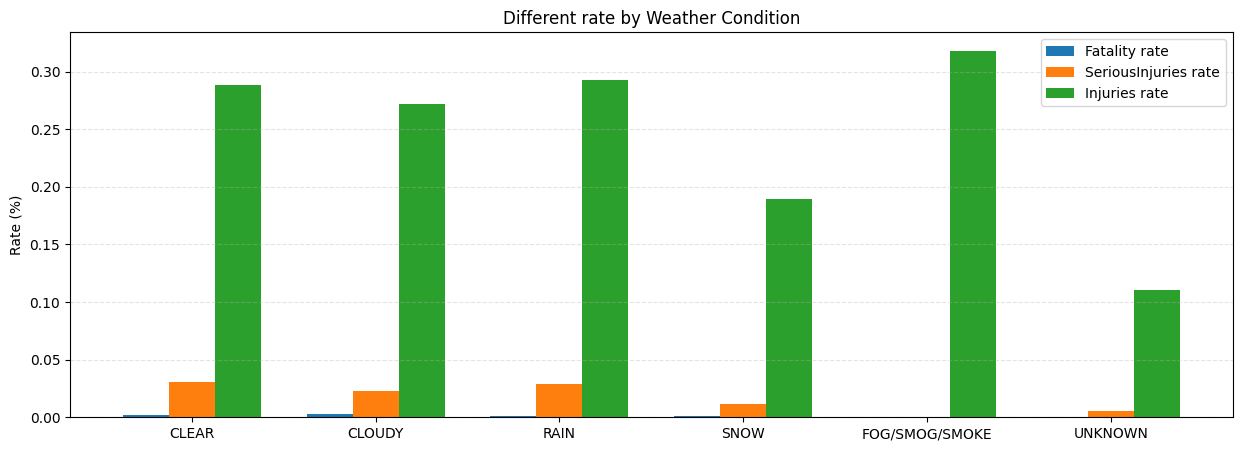

In [136]:
plot2_df = g2.copy()

order = ["CLEAR","CLOUDY","RAIN","SLEET/HAIL/FREEZING RAIN", "SNOW", "FOG/SMOG/SMOKE", "UNKNOWN"]
plot2_df = plot2_df.reindex([x for x in order if x in plot2_df.index])

f = plot2_df.index.tolist()
x = np.arange(len(f))
w = 0.25 

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w, plot2_df["Fatality_rate"] , width = w, label= "Fatality rate")
ax.bar(x,     plot2_df["SeriousInjuries_rate"] , width = w, label= "SeriousInjuries rate")
ax.bar(x + w, plot2_df["Injuries_rate"], width = w, label = "Injuries rate")



ax.set_xticks(x)
ax.set_xticklabels(f)
ax.set_ylabel("Rate (%)")
ax.set_title("Different rate by Weather Condition")

ax.yaxis.grid(True, linestyle="--", alpha = 0.35)
ax.legend()
plt.show()

In [107]:
g3 = (df10.groupby(["OnStreet_standardized","LightCondition_cleaned"]).agg(Crashes = ("LightCondition_cleaned", "size"), 
    Fatalities = ("NumberOfFatalities","sum"), SeriousInjuries=("NumberOfSeriousInjuries","sum"), Injuries=("NumberOfInjuries","sum"))).reset_index()

g3["Fatality_rate"] = g3["Fatalities"] / g3["Crashes"]
g3["SeriousInjuries_rate"] = g3["SeriousInjuries"] / g3["Crashes"]
g3["Injuries_rate"] = g3["Injuries"] / g3["Crashes"]

g3


,OnStreet_standardized,LightCondition_cleaned,Crashes,Fatalities,SeriousInjuries,Injuries,Fatality_rate,SeriousInjuries_rate,Injuries_rate
0,CHILI AVENUE,DARK-ROAD LIGHTED,776,2,32,222,0.002577,0.041237,0.286082
1,CHILI AVENUE,DARK-ROAD UNLIGHTED,65,0,4,12,0.000000,0.061538,0.184615
2,CHILI AVENUE,DAWN,48,0,0,14,0.000000,0.000000,0.291667
3,CHILI AVENUE,DAYLIGHT,2421,2,58,676,0.000826,0.023957,0.279223
4,CHILI AVENUE,DUSK,87,0,3,26,0.000000,0.034483,0.298851
5,CHILI AVENUE,UNKNOWN,41,0,0,1,0.000000,0.000000,0.024390
6,CLIFFORD AVENUE,DARK-ROAD LIGHTED,538,4,38,201,0.007435,0.070632,0.373606
7,CLIFFORD AVENUE,DARK-ROAD UNLIGHTED,12,0,0,3,0.000000,0.000000,0.250000
8,CLIFFORD AVENUE,DAWN,16,0,0,1,0.000000,0.000000,0.062500
9,CLIFFORD AVENUE,DAYLIGHT,1093,0,47,372,0.000000,0.043001,0.340348


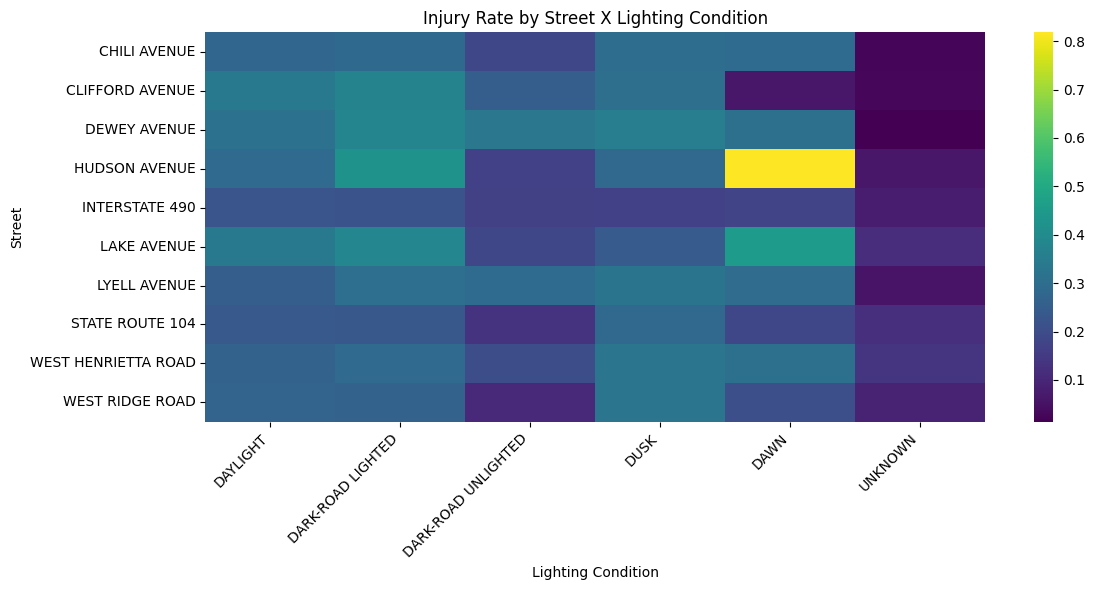

In [110]:
heat1 = g3.pivot(index = "OnStreet_standardized", columns = "LightCondition_cleaned", values = "Injuries_rate")
 
order = ["DAYLIGHT","DARK-ROAD LIGHTED","DARK-ROAD UNLIGHTED","DUSK","DAWN","UNKNOWN"]
heat = heat1.reindex(columns=[c for c in order if c in heat.columns])

fig, ax = plt.subplots(figsize = (12, 6))
sns.heatmap(heat, annot = False, ax = ax, cmap = "viridis") 

ax.set_title("Injury Rate by Street X Lighting Condition")
ax.set_xlabel("Lighting Condition")
ax.set_ylabel("Street")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

In [109]:
g4 = (df10.groupby(["OnStreet_standardized","WeatherCondition_cleaned"]).agg(Crashes = ("LightCondition_cleaned", "size"), 
    Fatalities = ("NumberOfFatalities","sum"), SeriousInjuries=("NumberOfSeriousInjuries","sum"), Injuries=("NumberOfInjuries","sum"))).reset_index()

g4["Fatality_rate"] = g4["Fatalities"] / g4["Crashes"]
g4["SeriousInjuries_rate"] = g4["SeriousInjuries"] / g4["Crashes"]
g4["Injuries_rate"] = g4["Injuries"] / g4["Crashes"]

g4


,OnStreet_standardized,WeatherCondition_cleaned,Crashes,Fatalities,SeriousInjuries,Injuries,Fatality_rate,SeriousInjuries_rate,Injuries_rate
0,CHILI AVENUE,CLEAR,1881,2,64,550,0.001063,0.034024,0.292398
1,CHILI AVENUE,CLOUDY,937,2,17,228,0.002134,0.018143,0.243330
2,CHILI AVENUE,RAIN,317,0,11,117,0.000000,0.034700,0.369085
3,CHILI AVENUE,SLEET/HAIL/FREEZING RAIN,11,0,0,1,0.000000,0.000000,0.090909
4,CHILI AVENUE,SNOW,232,0,4,48,0.000000,0.017241,0.206897
...,...,...,...,...,...,...,...,...,...
63,WEST RIDGE ROAD,FOG/SMOG/SMOKE,1,0,0,0,0.000000,0.000000,0.000000
64,WEST RIDGE ROAD,RAIN,573,1,10,143,0.001745,0.017452,0.249564
65,WEST RIDGE ROAD,SLEET/HAIL/FREEZING RAIN,29,0,0,5,0.000000,0.000000,0.172414
66,WEST RIDGE ROAD,SNOW,440,0,2,81,0.000000,0.004545,0.184091


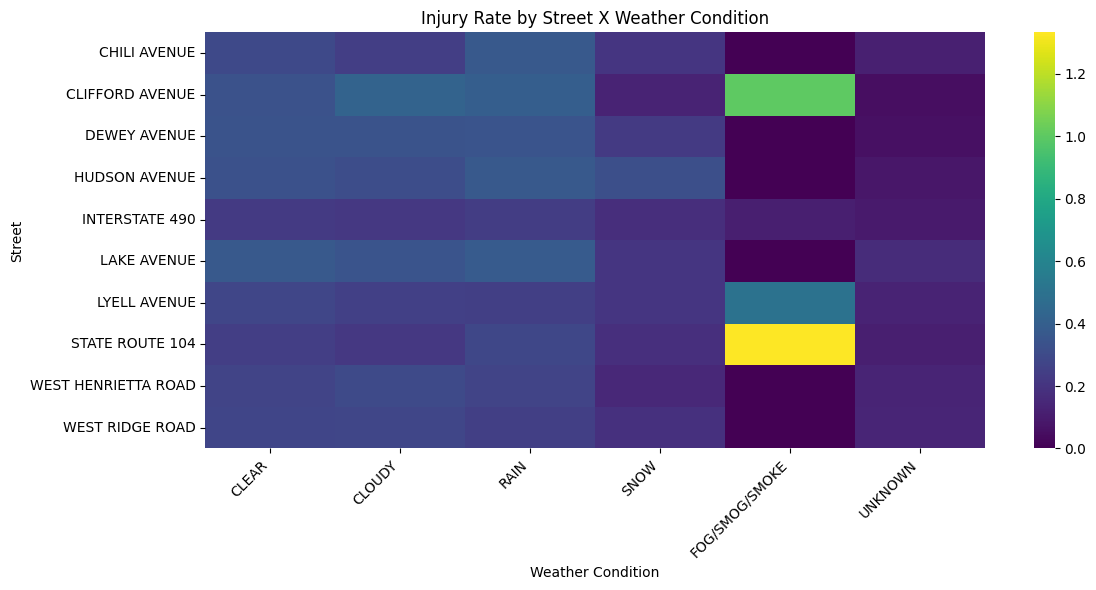

In [116]:
heat2 = g4.pivot(index = "OnStreet_standardized", columns = "WeatherCondition_cleaned", values = "Injuries_rate")
 
order = ["CLEAR","CLOUDY","RAIN","SLEET/HAIL/FREEZING RAIN", "SNOW", "FOG/SMOG/SMOKE", "UNKNOWN"]
heat2 = heat2.reindex(columns=[c for c in order if c in heat2.columns])

fig, ax = plt.subplots(figsize = (12, 6))
sns.heatmap(heat2.fillna(0), annot = False, ax = ax, cmap = "viridis") 

ax.set_title("Injury Rate by Street X Weather Condition")
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Street")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

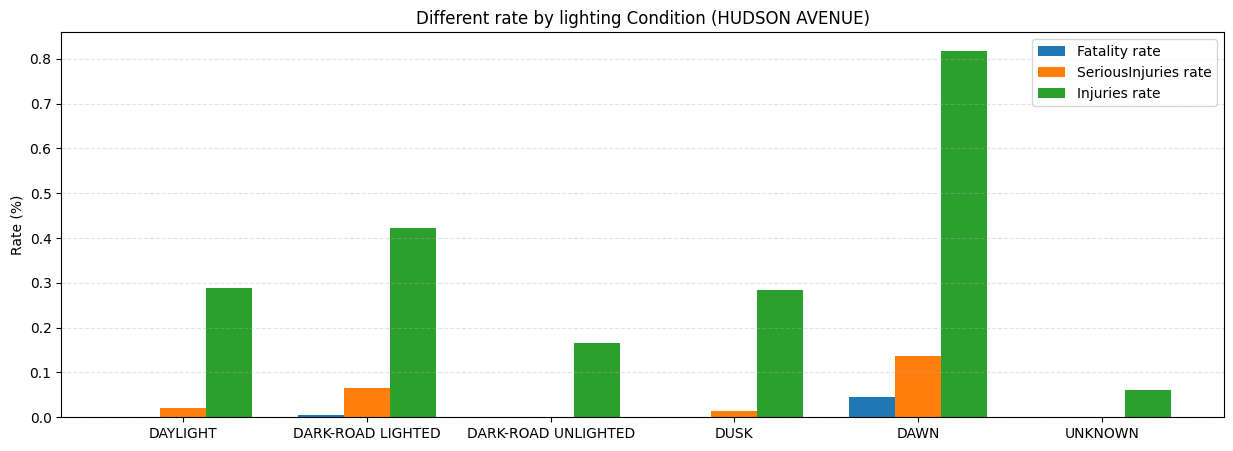

In [144]:
HA_slice = g3[g3["OnStreet_standardized"] == "HUDSON AVENUE"].copy()
HA_slice = HA_slice.drop(columns=["OnStreet_standardized"])
HA_slice = HA_slice.set_index("LightCondition_cleaned")

order = ["DAYLIGHT","DARK-ROAD LIGHTED","DARK-ROAD UNLIGHTED","DUSK","DAWN","UNKNOWN"]
HA_slice = HA_slice.reindex([x for x in order if x in HA_slice.index])

f = HA_slice.index.tolist()
x = np.arange(len(f))
w = 0.25 

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w, HA_slice["Fatality_rate"] , width = w, label= "Fatality rate")
ax.bar(x,     HA_slice["SeriousInjuries_rate"] , width = w, label= "SeriousInjuries rate")
ax.bar(x + w, HA_slice["Injuries_rate"], width = w, label = "Injuries rate")


ax.set_xticks(x)
ax.set_xticklabels(f)
ax.set_ylabel("Rate (%)")
ax.set_title("Different rate by lighting Condition (HUDSON AVENUE)")

ax.yaxis.grid(True, linestyle="--", alpha = 0.35)
ax.legend()
plt.show()

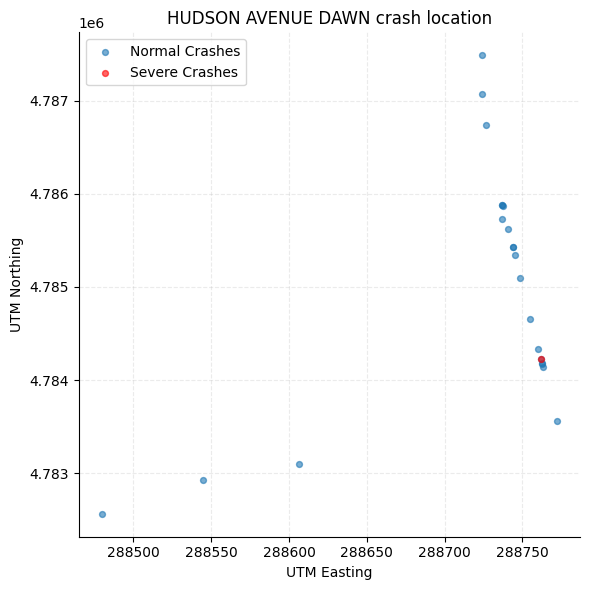

In [143]:

sl = df[(df["OnStreet_standardized"] == "HUDSON AVENUE") &
         (df["LightCondition_cleaned"] ==  "DAWN")].copy()

x = sl["UTMEasting"].to_numpy()
y = sl["UTMNorthing"].to_numpy()

sev = (sl["NumberOfFatalities"] > 0) | (sl["NumberOfSeriousInjuries"] > 0)
fig, ax = plt.subplots(figsize = (6, 6))
ax.scatter(x, y, s = 18, alpha = 0.6, label = "Normal Crashes")
ax.scatter(x[sev], y[sev], s = 18, alpha = 0.6, label = "Severe Crashes", color = "red")

ax.set_title("HUDSON AVENUE DAWN crash location")
ax.set_xlabel("UTM Easting")
ax.set_ylabel("UTM Northing")
ax.grid(True, linestyle="--", alpha = 0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

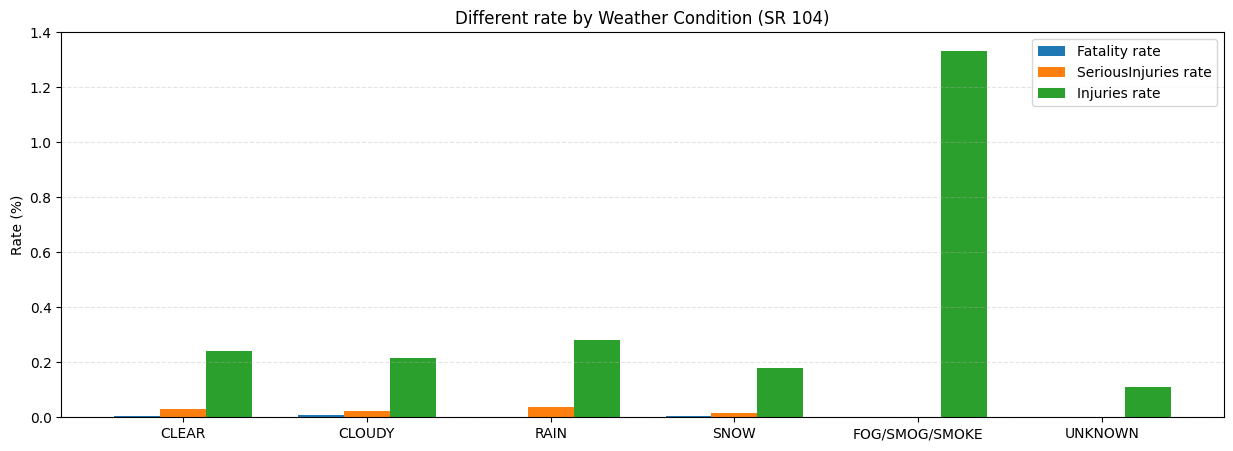

In [146]:
SR_slice = g4[g4["OnStreet_standardized"] == "STATE ROUTE 104"].copy()
SR_slice = SR_slice.drop(columns=["OnStreet_standardized"])
SR_slice = SR_slice.set_index("WeatherCondition_cleaned")

order =  ["CLEAR","CLOUDY","RAIN","SLEET/HAIL/FREEZING RAIN", "SNOW", "FOG/SMOG/SMOKE", "UNKNOWN"]
SR_slice = SR_slice.reindex([x for x in order if x in SR_slice.index])

f = SR_slice.index.tolist()
x = np.arange(len(f))
w = 0.25 

fig, ax = plt.subplots(figsize = (15, 5))
ax.bar(x - w, SR_slice["Fatality_rate"] , width = w, label= "Fatality rate")
ax.bar(x,     SR_slice["SeriousInjuries_rate"] , width = w, label= "SeriousInjuries rate")
ax.bar(x + w, SR_slice["Injuries_rate"], width = w, label = "Injuries rate")


ax.set_xticks(x)
ax.set_xticklabels(f)
ax.set_ylabel("Rate (%)")
ax.set_title("Different rate by Weather Condition (SR 104)")

ax.yaxis.grid(True, linestyle="--", alpha = 0.35)
ax.legend()
plt.show()

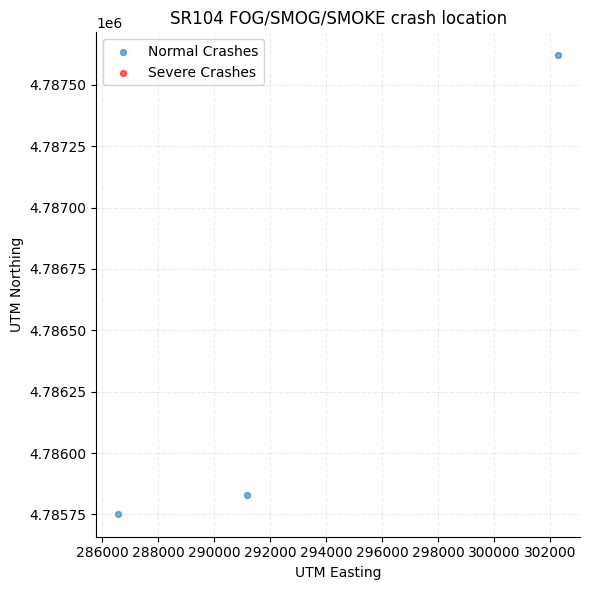

In [148]:


sl2 = df[(df["OnStreet_standardized"] == "STATE ROUTE 104") &
         (df["WeatherCondition_cleaned"] ==  "FOG/SMOG/SMOKE")].copy()

x = sl2["UTMEasting"].to_numpy()
y = sl2["UTMNorthing"].to_numpy()

sev = (sl2["NumberOfFatalities"] > 0) | (sl2["NumberOfSeriousInjuries"] > 0)
fig, ax = plt.subplots(figsize = (6, 6))
ax.scatter(x, y, s = 18, alpha = 0.6, label = "Normal Crashes")
ax.scatter(x[sev], y[sev], s = 18, alpha = 0.6, label = "Severe Crashes", color = "red")

ax.set_title("SR104 FOG/SMOG/SMOKE crash location")
ax.set_xlabel("UTM Easting")
ax.set_ylabel("UTM Northing")
ax.grid(True, linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

In [149]:
sl2

,CaseNumber,CaseYear,CrashDate,CrashTime,CrashTimeFormatted,CrashTypeCde,CrashType,CollisionType,CrashSeverity,LightCondition,...,DriverAgeVehicleThree,DriverAgeVehicleFour,DriverAgeVehicleFive,PersonTypes,PersonInjuries,ApparentFactors,ApparentFactorCodes,OnStreet_standardized,LightCondition_cleaned,WeatherCondition_cleaned
228495,34910092,2013,2013-08-29,739.0,7:39 AM,1,COLLISION WITH MOTOR VEHICLE,REAR END,INJURY,DAYLIGHT,...,NaN,NaN,NaN,U1:(DRIVER) / U2:(DRIVER),U1:(U - UNKNOWN) / U2:(U - UNKNOWN),"V1:(NOT APPLICABLE,NOT APPLICABLE) / V2:(FOLLO...",|777|777|9|19|,STATE ROUTE 104,DAYLIGHT,FOG/SMOG/SMOKE
228574,37870626,2019,2019-05-02,853.0,8:53 AM,1,COLLISION WITH MOTOR VEHICLE,REAR END,INJURY,DAYLIGHT,...,NaN,NaN,NaN,U1:(DRIVER) / U2:(DRIVER),U1:(U - UNKNOWN) / U2:(U - UNKNOWN),"V1:(FOLLOWING TOO CLOSELY,DRIVER INATTENTION) ...",|9|4|777|777|,STATE ROUTE 104,DAYLIGHT,FOG/SMOG/SMOKE
229618,37284652,2018,2018-05-16,757.0,7:57 AM,1,COLLISION WITH MOTOR VEHICLE,REAR END,INJURY,DAYLIGHT,...,NaN,NaN,NaN,U1:(DRIVER) / U2:(DRIVER),U1:(U - UNKNOWN) / U2:(U - UNKNOWN),"V1:(FOLLOWING TOO CLOSELY,REACTION TO OTHER UN...",|9|26|777|777|,STATE ROUTE 104,DAYLIGHT,FOG/SMOG/SMOKE


In [150]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

tmp = df.copy()
tmp = tmp[(tmp["WeatherCondition_cleaned"].notna()) & (tmp["LightCondition_cleaned"].notna())]

ct = pd.crosstab(tmp["WeatherCondition_cleaned"], tmp["LightCondition_cleaned"])
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)
print("chi2 =", chi2, "dof =", dof, "p-value =", p)

n = ct.to_numpy().sum()
r, k = ct.shape
cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
print("Cramér's V =", cramers_v)

LightCondition_cleaned     DARK-ROAD LIGHTED  DARK-ROAD UNLIGHTED  DAWN  \
WeatherCondition_cleaned                                                  
CLEAR                                  28220                 9693  2071   
CLOUDY                                 14580                 6327  1805   
FOG/SMOG/SMOKE                            50                   69    38   
RAIN                                    6699                 1782   584   
SLEET/HAIL/FREEZING RAIN                 586                  211    47   
SNOW                                    7178                 2081   598   
UNKNOWN                                  416                  181    18   

LightCondition_cleaned     DAYLIGHT  DUSK  UNKNOWN  
WeatherCondition_cleaned                            
CLEAR                        111469  3550      261  
CLOUDY                        54417  2151      109  
FOG/SMOG/SMOKE                   66     6        0  
RAIN                          14848   607       34  
SLEET/